# 💰 Financial Analytics: Company Performance Analysis

**Dataset:** [Microsoft Financial Sample](https://www.kaggle.com/datasets/atharvaarya25/financials)  
**Records:** 700 transactions · 5 countries · 5 segments · 2013–2014  
**Tools:** Python · pandas · matplotlib

---

## 🎯 Project Goal

Analyse company financial performance across time, segments, and geography.  
Identify growth trends, profitability, seasonality patterns, and business risks.

---

## 📋 Contents

1. Setup & Data Loading  
2. Data Overview  
3. Data Cleaning  
4. Revenue & Profit by Year  
5. Profit Margin by Year  
6. Sales by Segment  
7. Monthly Seasonality  
8. Sales by Country  
9. Business Conclusion

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Financials.csv')
df.shape

(700, 16)

## 2. Data Overview

Key columns:
- **Segment** — client type (Government, Small Business, Enterprise, Midmarket, Channel Partners)
- **Country** — 5 markets (USA, Canada, France, Germany, Mexico)
- **Sales** — revenue after discounts
- **COGS** — Cost of Goods Sold (production cost)
- **Profit** — Sales minus COGS
- **Month Number / Year** — time dimension

In [2]:
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,"$1,618.50",$3.00,$20.00,"$32,370.00",$-,"$32,370.00","$16,185.00","$16,185.00",01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,"$1,321.00",$3.00,$20.00,"$26,420.00",$-,"$26,420.00","$13,210.00","$13,210.00",01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,"$2,178.00",$3.00,$15.00,"$32,670.00",$-,"$32,670.00","$21,780.00","$10,890.00",01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,$888.00,$3.00,$15.00,"$13,320.00",$-,"$13,320.00","$8,880.00","$4,440.00",01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,"$2,470.00",$3.00,$15.00,"$37,050.00",$-,"$37,050.00","$24,700.00","$12,350.00",01/06/2014,6,June,2014


In [3]:
df.columns.tolist()

['Segment',
 'Country',
 ' Product ',
 ' Discount Band ',
 ' Units Sold ',
 ' Manufacturing Price ',
 ' Sale Price ',
 ' Gross Sales ',
 ' Discounts ',
 '  Sales ',
 ' COGS ',
 ' Profit ',
 'Date',
 'Month Number',
 ' Month Name ',
 'Year']

## 3. Data Cleaning

Financial data often comes dirty from Excel:
- Column names have leading/trailing spaces → `str.strip()`
- Numbers stored as strings with `$` and `,` → `str.replace()`
- Negative numbers in accounting format `(4533.75)` → regex conversion
- Missing values stored as `-` → replace with 0

In [4]:
df.columns = df.columns.str.strip()

money_cols = ['Units Sold', 'Manufacturing Price', 'Sale Price',
              'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit']

for col in money_cols:
    df[col] = (df[col].astype(str)
               .str.replace(r'[\$,\s]', '', regex=True)
               .str.replace(r'\((\d+\.?\d*)\)', r'-\1', regex=True)
               .replace('-', '0')
               .astype(float))

df[money_cols].dtypes

,0
Units Sold,float64
Manufacturing Price,float64
Sale Price,float64
Gross Sales,float64
Discounts,float64
Sales,float64
COGS,float64
Profit,float64


## 4. Revenue & Profit by Year

How did the company grow year over year?  
We sum Sales and Profit per year and convert to millions for readability.

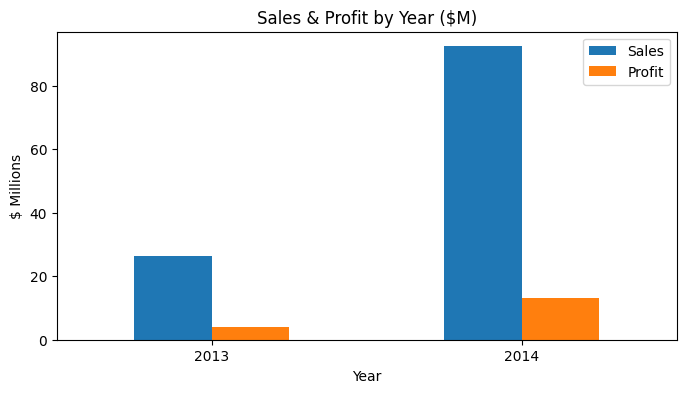

In [5]:
yearly = df.groupby('Year')[['Sales', 'Profit']].sum() / 1_000_000

yearly.plot(kind='bar', figsize=(8, 4), title='Sales & Profit by Year ($M)')
plt.ylabel('$ Millions')
plt.xticks(rotation=0)
plt.show()

**Key insight:** Revenue grew **3.5x** — from $26M (2013) to $90M (2014).  
Profit also grew proportionally, suggesting healthy scaling.

## 5. Profit Margin by Year

Profit Margin = Profit / Sales × 100%  
Shows how many cents of profit the company earns per dollar of revenue.

/tmp/ipykernel_3618/1320259042.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  margin = df.groupby('Year').apply(


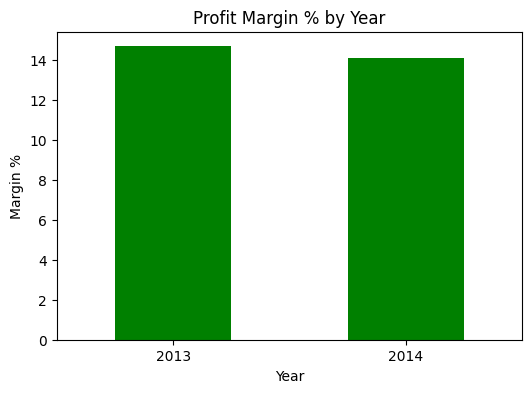

In [6]:
margin = df.groupby('Year').apply(
    lambda x: x['Profit'].sum() / x['Sales'].sum() * 100
).round(1)

margin.plot(kind='bar', color='green', figsize=(6, 4), title='Profit Margin % by Year')
plt.ylabel('Margin %')
plt.xticks(rotation=0)
plt.show()

**Key insight:** Margin stayed stable — 14.7% (2013) vs 14.5% (2014).  
Revenue grew 3.5x with no margin erosion — the company scales **efficiently**.

## 6. Sales by Segment

Which client segments drive the most revenue?

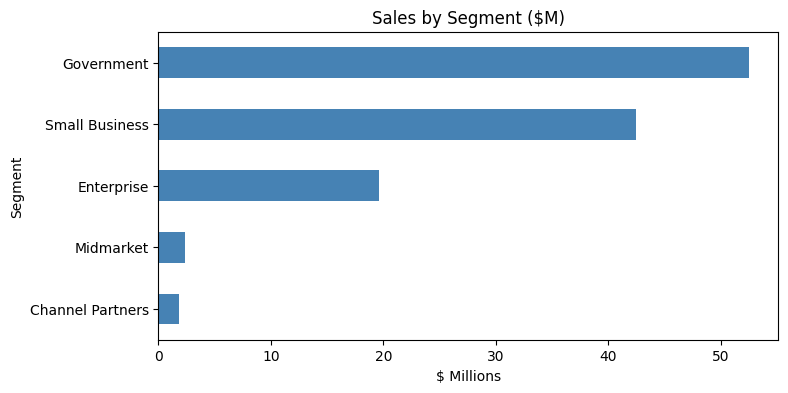

In [7]:
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values() / 1_000_000

segment_sales.plot(kind='barh', color='steelblue', figsize=(8, 4), title='Sales by Segment ($M)')
plt.xlabel('$ Millions')
plt.show()

**Key insight:** Government (46%) and Small Business (37%) together generate **83% of revenue**.  
⚠️ High concentration risk — losing Government contracts would cut revenue by half.

## 7. Monthly Seasonality

Is there a seasonal pattern in sales?  
We aggregate by month number and plot a line chart.

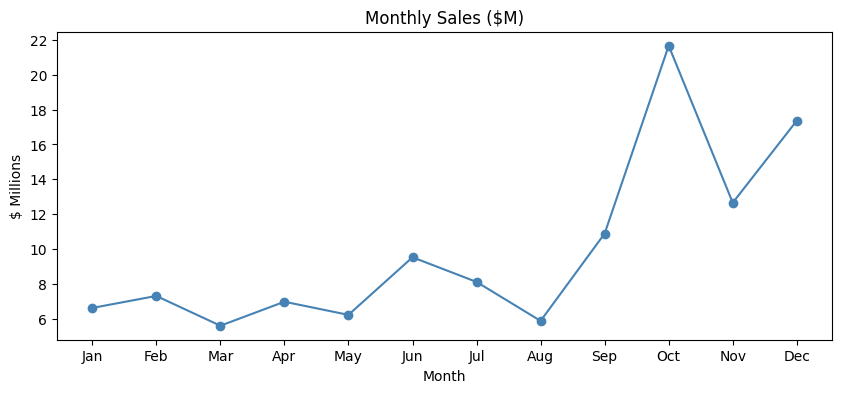

In [8]:
monthly = df.groupby('Month Number')['Sales'].sum() / 1_000_000

monthly.plot(kind='line', marker='o', color='steelblue', figsize=(10, 4), title='Monthly Sales ($M)')
plt.xlabel('Month')
plt.ylabel('$ Millions')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()

**Key insight:** Strong October peak ($22M) — 3.5x above monthly average.  
Classic **B2G pattern**: government budgets expire at year-end, driving Q4 spending.  
⚠️ Over 50% of annual revenue comes in just 3 months (Oct–Dec).

## 8. Sales by Country

How is revenue distributed across markets?

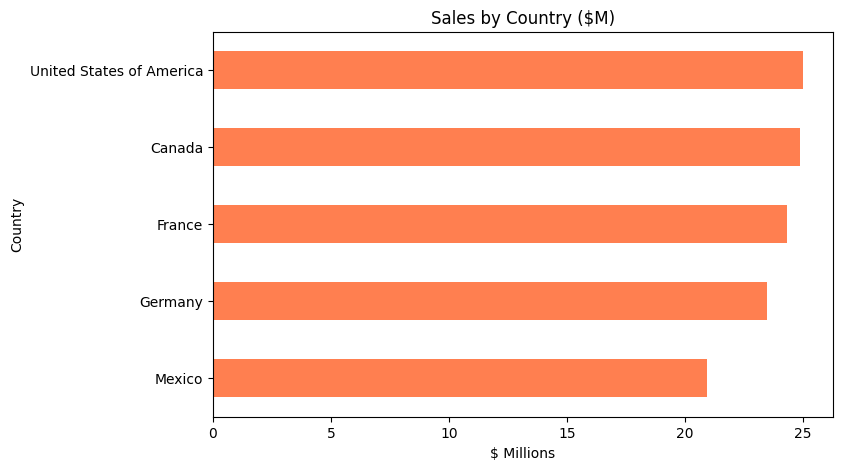

In [9]:
country_sales = df.groupby('Country')['Sales'].sum().sort_values() / 1_000_000

country_sales.plot(kind='barh', color='coral', figsize=(8, 5), title='Sales by Country ($M)')
plt.xlabel('$ Millions')
plt.show()

**Key insight:** All 5 countries contribute equally (~$21–25M each).  
No single-country dependency — strong **geographic diversification**. ✅

## 9. Business Conclusion

**Dataset:** Microsoft Financial Sample · 700 records · 2013–2014

**Goal:** Analyse company financial performance across time, segments, and geography.

**Key Findings:**

1. **Revenue grew 3.5x** — from 26M (2013) to 90M (2014)
2. **Profit Margin stable** — 14.7% in 2013 vs 14.5% in 2014 — company scales efficiently
3. **Top segments:** Government (46%) and Small Business (37%) — together 83% of revenue  
   ⚠️ High concentration risk — loss of Government contracts would cut revenue by half
4. **Strong seasonality** — October peak (22M) is 3.5x above monthly average  
   Typical B2G pattern: government budget year-end spending
5. **Geographic diversification** — 5 countries, all contributing ~21–25M equally  
   No single-country dependency risk ✅

**Recommendation:**  
Maintain Government and Small Business focus while developing Enterprise segment.  
Plan cash flow around October–December peak season.  
Geographic diversification is a strength — consider expanding to new markets.